Imports

In [1]:
%matplotlib inline

In [2]:
from ipywidgets import interact, interactive
from IPython.display import clear_output, display, HTML

In [4]:
import numpy as np
from scipy import integrate

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import cnames
from matplotlib import animation

Computing the Trajectories and Plotting the Result

In [9]:
def solve_lorenz(N=10, angle=0.0, max_time = 4.0, sigma = 10.0, beta = 8./3, rho = 28.0):

		fig = plt.figure();
		ax = fig.add_axes([0, 0, 1, 1], projection = '3d');
		ax.axis('off')

		# Prepare the axes limits
		ax.set_xlim((-25, 25))
		ax.set_ylim((-35, 35))
		ax.set_zlim((5, 55))

		def lorenz_deriv(x_y_z, t0, sigma=sigma, beta=beta, rho=rho):
			"Compute the time-derivative of a Lorenz system."
			x, y, z, = x_y_z
			return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

		# Choose random starting points, uniformly distributed from -15 to 15
		np.random.seed(1)
		x0 = -15 + 30 * np.random.random((N, 3))

		# Solve for the trajectories
		t = np.linspace(0, max_time, int(250*max_time))
		x_t  = np.asarray([integrate.odeint(lorenz_deriv, x0i, t)
			for x0i in x0])

		# Choose a different color for each trajectory
		colors = plt.cm.jet(np.linspace(0, 1, N));

		for i in range(N):
			x, y, z = x_t[i,:,:].T
			line = ax.plot(x, y, z, '-', c=colors[i])
			_ = plt.setp(lines, linewidth=2);

		ax.view_init(30, angle)
		_ = plt.show();

		return t, x_t


Let’s call the function once to view the solutions. For this set of parameters, we see the trajectories swirling around two points, called attractors.

NameError: name 'x' is not defined

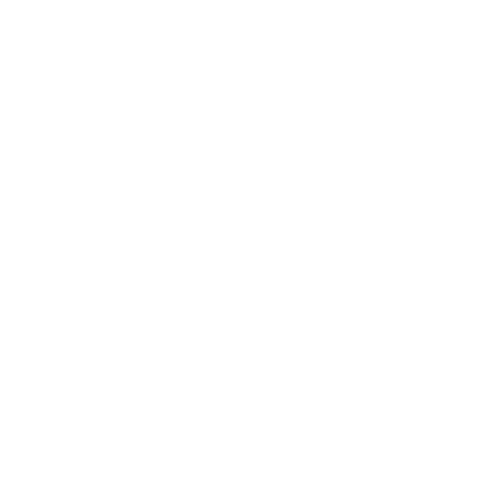

In [8]:
t, x_t = solve_lorenz(angle=0, N=10)

Using IPython’s “Interactive” Function, we can explore how the trajectories behave as we change the various parameters.

In [14]:
w = interactive(solve_lorenz, angle = (0.,360.), N = (0,50), sigma=(0.0, 50.0), rho(0.0,50.0)), display(w);

SyntaxError: positional argument follows keyword argument (3709827136.py, line 1)

The object returned by interactive is a Widget object and it has attributes that contain the current result and arguments:

In [15]:
t, x_t = w.result

NameError: name 'w' is not defined

In [16]:
w.kwargs

NameError: name 'w' is not defined

After interacting with the system, we can take the result and perform further computations. In this case, we compute the average positions in x, y, and z.

In [17]:
xyz_avg = x_t.mean(axis=1)

NameError: name 'x_t' is not defined

In [18]:
xyz_avg.shape

NameError: name 'xyz_avg' is not defined

Creating histograms of the average positions (across different trajectories) show that on average the trajectories swirl about the attractors.

NOTE: These will look different from the lecture version if you adjusted any of the sliders in the interactive widget and changed the parameters.


In [19]:
plt.hist(xyz_avg[:,0])
plt.title('Average $x(t)$');

NameError: name 'xyz_avg' is not defined

In [20]:
 plt.hist(xyz_avg[:,1])
plt.title('Average $y(t)$');

NameError: name 'xyz_avg' is not defined